# 01 – Weather Station EDA
Hourly 2025 readings from 40 NUS campus weather stations (City Syntax Lab). Method and findings are written up in the paper and slides.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW = Path("../data/raw")
files = sorted(RAW.glob("NUS_CAMPUS_WS*_2025_Hourly.csv"))
print(len(files), "files found")

40 files found


In [128]:
frames = []
for f in files:
    d = pd.read_csv(f, parse_dates=["Datetime"])
    d["Station"] = f.name.split("_")[2]   # e.g. "WS01"
    frames.append(d)

df = pd.concat(frames, ignore_index=True)

print(df.shape)
display(df.head())
df.info()

(349590, 11)


,Datetime,Latitude,Longitude,WindSpeed Ave (m/s),WindDir Ave (degrees),AirTemp Ave (C),RelHum Ave (%),AtmPress Ave (hPa),GlobalRad Ave (W/m2),Station,Rain Tot (mm)
0,2025-01-01 00:00:00,1.300666,103.771232,0.517148,131.040439,25.782881,91.496610,1008.647458,0.0,WS01,NaN
1,2025-01-01 01:00:00,1.300666,103.771232,0.554134,131.457858,25.839000,91.136667,1008.288333,0.0,WS01,NaN
2,2025-01-01 02:00:00,1.300666,103.771232,0.729291,134.155274,25.766500,91.260000,1007.598333,0.0,WS01,NaN
3,2025-01-01 03:00:00,1.300666,103.771232,0.538654,133.938148,25.509500,92.063333,1006.823333,0.0,WS01,NaN
4,2025-01-01 04:00:00,1.300666,103.771232,0.499675,127.333428,25.353833,92.536667,1006.203333,0.0,WS01,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349590 entries, 0 to 349589
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Datetime               349590 non-null  datetime64[ns]
 1   Latitude               349590 non-null  float64       
 2   Longitude              349590 non-null  float64       
 3   WindSpeed Ave (m/s)    335381 non-null  float64       
 4   WindDir Ave (degrees)  335381 non-null  float64       
 5   AirTemp Ave (C)        335381 non-null  float64       
 6   RelHum Ave (%)         335381 non-null  float64       
 7   AtmPress Ave (hPa)     335381 non-null  float64       
 8   GlobalRad Ave (W/m2)   325335 non-null  float64       
 9   Station                349590 non-null  object        
 10  Rain Tot (mm)          26280 non-null   float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 29.3+ MB


In [129]:
## 03. Dataset structure
df = df.rename(columns={
    "Datetime": "datetime",
    "Latitude": "lat",
    "Longitude": "lon",
    "WindSpeed Ave (m/s)": "wind_speed",
    "WindDir Ave (degrees)": "wind_dir",
    "AirTemp Ave (C)": "temp",
    "RelHum Ave (%)": "rh",
    "AtmPress Ave (hPa)": "pressure",
    "GlobalRad Ave (W/m2)": "solar",
    "Rain Tot (mm)": "rain",
})
df.columns.tolist()

['datetime',
 'lat',
 'lon',
 'wind_speed',
 'wind_dir',
 'temp',
 'rh',
 'pressure',
 'solar',
 'Station',
 'rain']

In [130]:
station_summary = (
    df.groupby("Station")
      .agg(rows=("datetime", "size"),
           first=("datetime", "min"),
           last=("datetime", "max"),
           lat=("lat", "first"),
           lon=("lon", "first"),
           n_locations=("lat", "nunique"))
)
station_summary["missing_rows"] = 8760 - station_summary["rows"]

print("Stations:", df["Station"].nunique())
print("Date range:", df["datetime"].min(), "→", df["datetime"].max())
display(station_summary.sort_values("missing_rows", ascending=False))

Stations: 40
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00


,rows,first,last,lat,lon,n_locations,missing_rows
Station,,,,,,,
WS38,8325,2025-01-01 00:00:00,2025-12-13 20:00:00,1.305473,103.773064,1,435
WS06,8443,2025-01-01 00:00:00,2025-12-18 18:00:00,1.298318,103.770400,1,317
WS17,8717,2025-01-01 00:00:00,2025-12-30 04:00:00,1.292331,103.774516,1,43
WS31,8748,2025-01-01 12:00:00,2025-12-31 23:00:00,1.296682,103.780151,1,12
WS20,8758,2025-01-01 00:00:00,2025-12-31 21:00:00,1.292916,103.779062,1,2
WS30,8759,2025-01-01 00:00:00,2025-12-31 22:00:00,1.295731,103.779872,1,1
WS01,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.300666,103.771232,1,0
WS25,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.297994,103.777999,1,0
WS26,8760,2025-01-01 00:00:00,2025-12-31 23:00:00,1.298145,103.777511,1,0


In [131]:
key = ["temp", "rh", "wind_speed", "wind_dir", "pressure", "solar"]
(df[key].isna().mean() * 100).round(2)

temp          4.06
rh            4.06
wind_speed    4.06
wind_dir      4.06
pressure      4.06
solar         6.94
dtype: float64

In [132]:
miss_station = (df[key].isna().groupby(df["Station"]).mean() * 100).round(1)
display(miss_station.sort_values("temp", ascending=False).head(10))

,temp,rh,wind_speed,wind_dir,pressure,solar
Station,,,,,,
WS11,26.6,26.6,26.6,26.6,26.6,26.6
WS34,21.1,21.1,21.1,21.1,21.1,21.1
WS32,19.5,19.5,19.5,19.5,19.5,10.5
WS14,16.4,16.4,16.4,16.4,16.4,15.9
WS07,11.2,11.2,11.2,11.2,11.2,11.3
WS33,10.2,10.2,10.2,10.2,10.2,10.2
WS17,9.7,9.7,9.7,9.7,9.7,9.6
WS15,9.3,9.3,9.3,9.3,9.3,9.3
WS31,8.4,8.4,8.4,8.4,8.4,8.4


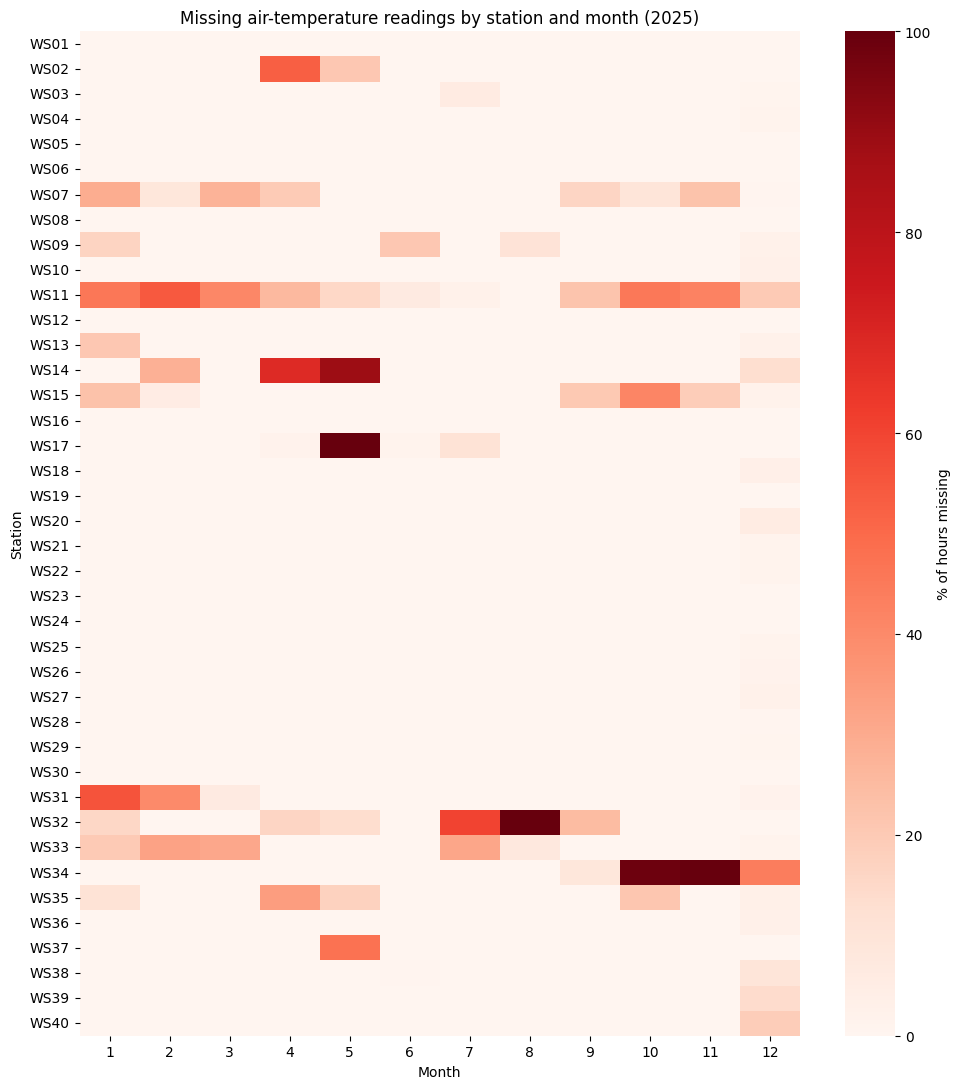

In [133]:
df["month"] = df["datetime"].dt.month
miss_month = (df["temp"].isna()
                .groupby([df["Station"], df["month"]]).mean()
                .unstack() * 100)

plt.figure(figsize=(10, 11))
sns.heatmap(miss_month, cmap="Reds", vmin=0, vmax=100,
            cbar_kws={"label": "% of hours missing"})
plt.title("Missing air-temperature readings by station and month (2025)")
plt.xlabel("Month")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

## 05. Data quality – implausible readings

In [134]:
df[key].describe().T[["min", "mean", "max"]].round(1)

,min,mean,max
temp,21.4,28.7,39.5
rh,37.6,80.5,99.5
wind_speed,0.0,0.7,17.0
wind_dir,0.0,185.3,360.0
pressure,459.9,1001.8,1016.4
solar,0.0,140.0,1500.0


In [135]:
limits = {
    "temp":       (20, 37),
    "rh":         (0, 100),
    "pressure":   (980, 1030),
    "wind_speed": (0, 10),
    "solar":      (0, 1200),
}

for var, (lo, hi) in limits.items():
    bad = df[(df[var] < lo) | (df[var] > hi)]
    print(f"{var:10s} outside {lo}–{hi}: {len(bad):5d} readings | "
          f"worst stations: {bad['Station'].value_counts().head(3).to_dict()}")

temp       outside 20–37:   294 readings | worst stations: {'WS22': 163, 'WS34': 29, 'WS26': 21}
rh         outside 0–100:     0 readings | worst stations: {}
pressure   outside 980–1030:  2868 readings | worst stations: {'WS17': 2868}
wind_speed outside 0–10:    41 readings | worst stations: {'WS17': 41}
solar      outside 0–1200:   802 readings | worst stations: {'WS23': 758, 'WS26': 32, 'WS07': 12}


In [136]:
night = df[df["datetime"].dt.hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5])]
night_solar = (night.groupby("Station")["solar"]
                    .agg(mean="mean", max="max").round(1)
                    .sort_values("mean", ascending=False))
display(night_solar.head(8))
print("Median station's mean night-time solar:", night_solar["mean"].median())

,mean,max
Station,,
WS23,389.7,1500.0
WS39,206.4,223.1
WS32,143.3,152.9
WS07,53.5,1020.1
WS26,50.2,767.5
WS19,33.5,1013.5
WS11,0.4,5.6
WS14,0.4,11.0


Median station's mean night-time solar: 0.0


## 05b. Statistical outlier screening (Stage 1)
Modified z-score against the campus median, and a frozen-sensor (persistence) test.

In [137]:
resolution = {"temp": 0.1, "rh": 0.5, "wind_speed": 0.1, "pressure": 0.1, "solar": 1.0}
hr = df["datetime"].dt.hour

stat_flag = {}
rows = []
for var, floor in resolution.items():
    dev = df[var] - df.groupby("datetime")[var].transform("median")
    spread = dev.groupby(hr).transform(
        lambda x: max(1.4826 * np.nanmedian(np.abs(x - np.nanmedian(x))), floor))
    z = dev / spread
    stat_flag[var] = (z.abs() > 3.5) & df[var].notna()

    by_station = stat_flag[var].groupby(df["Station"]).mean().sort_values(ascending=False)
    rows.append({
        "variable": var,
        "valid readings": int(df[var].notna().sum()),
        "flagged": int(stat_flag[var].sum()),
        "% flagged": round(stat_flag[var].sum() / df[var].notna().sum() * 100, 1),
        "most-flagged stations": ", ".join(f"{s} ({p*100:.0f}%)" for s, p in by_station.head(3).items()),
    })

display(pd.DataFrame(rows).set_index("variable"))

d_sorted = df.sort_values(["Station", "datetime"])
def frozen(col, n=6):
    x = d_sorted[col]
    new_run = (x != x.groupby(d_sorted["Station"]).shift()) | x.isna() | \
              d_sorted["Station"].ne(d_sorted["Station"].shift())
    size = x.groupby(new_run.cumsum()).transform("size")
    return ((size >= n) & x.notna() & (x != 0)).reindex(df.index)

frozen_flag = {v: frozen(v) for v in ["temp", "rh", "wind_speed", "wind_dir", "pressure", "solar"]}
display(pd.DataFrame([{
    "variable": v,
    "readings in frozen runs": int(f.sum()),
    "stations": ", ".join(f"{s} ({n})" for s, n in
                          df.loc[f, "Station"].value_counts().head(4).items()),
} for v, f in frozen_flag.items()]).set_index("variable"))

,valid readings,flagged,% flagged,most-flagged stations
variable,,,,
temp,335381,9946,3.0,"WS20 (36%), WS22 (11%), WS27 (11%)"
rh,335381,5058,1.5,"WS20 (23%), WS22 (11%), WS03 (3%)"
wind_speed,335381,22267,6.6,"WS16 (64%), WS02 (63%), WS35 (44%)"
pressure,335381,2868,0.9,"WS17 (33%), WS01 (0%), WS22 (0%)"
solar,325335,27135,8.3,"WS39 (66%), WS32 (59%), WS26 (45%)"


,readings in frozen runs,stations
variable,,
temp,0,
rh,18,WS24 (18)
wind_speed,143,WS17 (143)
wind_dir,147,WS17 (147)
pressure,0,
solar,75,"WS32 (50), WS07 (19), WS08 (6)"


## 06. Cleaning rules (Stage 2)
Physical tests decide what is removed. Rules and counts: see the paper (Table 1) and `outputs/tables/quality_flags.csv`.

In [138]:
clean = df.copy()
log = []

def mask_to_nan(mask, col, rule):
    """Set flagged readings to NaN (blank) and record how many were changed."""
    mask = np.asarray(mask, dtype=bool)
    n = int((mask & clean[col].notna().to_numpy()).sum())
    clean.loc[mask, col] = np.nan
    log.append({"rule": rule, "variable": col, "readings_set_to_NaN": n})

hour  = clean["datetime"].dt.hour
month = clean["datetime"].dt.month
is_night = hour.isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5])

def cos_zenith(dt, lat, lon, tz=8):
    """Cosine of the solar zenith angle (NOAA approximation); tz = hours ahead of UTC."""
    doy = dt.dt.dayofyear.to_numpy()
    h = (dt.dt.hour + dt.dt.minute / 60).to_numpy()
    g = 2 * np.pi / 365 * (doy - 1 + (h - 12) / 24)
    eqt = 229.18 * (0.000075 + 0.001868*np.cos(g) - 0.032077*np.sin(g)
                    - 0.014615*np.cos(2*g) - 0.040849*np.sin(2*g))
    dec = (0.006918 - 0.399912*np.cos(g) + 0.070257*np.sin(g) - 0.006758*np.cos(2*g)
           + 0.000907*np.sin(2*g) - 0.002697*np.cos(3*g) + 0.00148*np.sin(3*g))
    tst = h * 60 + eqt + 4 * lon.to_numpy() - 60 * tz
    ha = np.radians(tst / 4 - 180)
    la = np.radians(lat.to_numpy())
    return np.sin(la) * np.sin(dec) + np.cos(la) * np.cos(dec) * np.cos(ha)

mu0 = np.clip(cos_zenith(clean["datetime"], clean["lat"], clean["lon"]), 0, None)
doy = clean["datetime"].dt.dayofyear.to_numpy()
S_a = 1361 * (1 + 0.033 * np.cos(2 * np.pi * doy / 365))
solar_max = S_a * 1.5 * mu0**1.2 + 100

solar_night = is_night & (clean["solar"] > 50)
solar_bsrn  = hour.between(9, 16) & (clean["solar"] > solar_max)
phys_fail = {
    "solar":      solar_night | solar_bsrn,
    "pressure":   (clean["pressure"] < 980) | (clean["pressure"] > 1030),
    "wind_speed": clean["wind_speed"] > 10,
    "rh":         (clean["rh"] < 0) | (clean["rh"] > 100),
}

check = []
for var, p in phys_fail.items():
    s = stat_flag[var]
    check.append({"variable": var,
                  "statistical + physical (removed)": int((p & s).sum()),
                  "physical only (removed)": int((p & ~s).sum()),
                  "statistical only (kept)": int((~p & s).sum())})
display(pd.DataFrame(check).set_index("variable"))

night_rows = clean[is_night & clean["solar"].notna()]
share_bad = (night_rows["solar"] > 50).groupby([night_rows["Station"], night_rows["month"]]).mean()
faulty_months = share_bad[share_bad >= 0.5].index
in_faulty_month = pd.MultiIndex.from_arrays([clean["Station"], month]).isin(faulty_months)

mask_to_nan(in_faulty_month, "solar",
            "solar: station-months with >= 50% of night readings above 50 W/m2 (whole month)")
mask_to_nan(solar_night, "solar", "solar > 50 W/m2 at night (20:00-05:59), remaining readings")
mask_to_nan(solar_bsrn,  "solar", "solar above BSRN physically-possible limit (09:00-16:59)")
mask_to_nan(phys_fail["pressure"], "pressure", "pressure outside 980-1030 hPa")
mask_to_nan(frozen_flag["wind_speed"], "wind_speed",
            "wind speed: same value repeated 6+ hours (frozen sensor, WS17 December)")
mask_to_nan(frozen_flag["wind_dir"], "wind_dir",
            "wind direction: same value repeated 6+ hours (frozen sensor, WS17 December)")
mask_to_nan(phys_fail["wind_speed"], "wind_speed", "wind speed > 10 m/s, remaining readings")
mask_to_nan(phys_fail["rh"], "rh", "relative humidity outside 0-100%")

clean["temp_hot_flag"] = clean["temp"] > 37

quality_log = pd.DataFrame(log)
display(quality_log)
print("Temperature readings flagged (kept):", clean["temp_hot_flag"].sum())
print("Solar station-months removed:", {s: sorted(m for st, m in faulty_months if st == s)
                                       for s in sorted({st for st, _ in faulty_months})})

quality_log.to_csv("../outputs/tables/quality_flags.csv", index=False)

,statistical + physical (removed),physical only (removed),statistical only (kept)
variable,,,
solar,10425,0,16710
pressure,2868,0,0
wind_speed,41,0,22226
rh,0,0,5058


,rule,variable,readings_set_to_NaN
0,solar: station-months with >= 50% of night rea...,solar,24432
1,"solar > 50 W/m2 at night (20:00-05:59), remain...",solar,578
2,solar above BSRN physically-possible limit (09...,solar,11
3,pressure outside 980-1030 hPa,pressure,2868
4,wind speed: same value repeated 6+ hours (froz...,wind_speed,143
5,wind direction: same value repeated 6+ hours (...,wind_dir,147
6,"wind speed > 10 m/s, remaining readings",wind_speed,5
7,relative humidity outside 0-100%,rh,0


Temperature readings flagged (kept): 294
Solar station-months removed: {'WS07': [10, 11, 12], 'WS23': [3, 4, 5, 6, 7, 8, 9], 'WS26': [10, 11, 12], 'WS32': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'WS39': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}


## 07. Daily temperature cycle

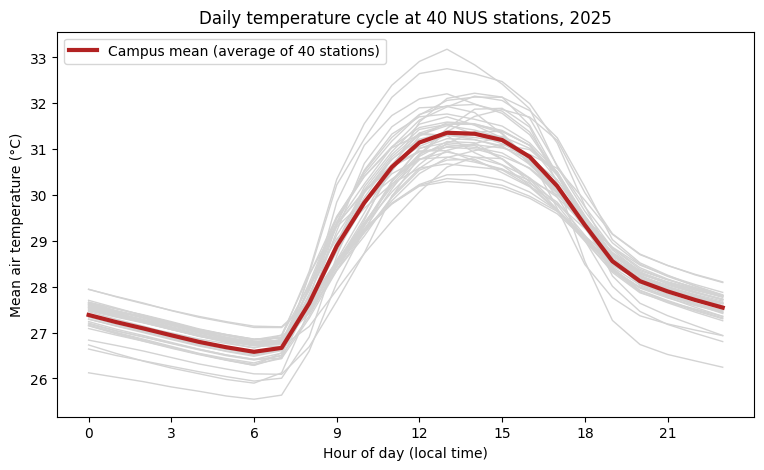

In [139]:
clean["hour"] = clean["datetime"].dt.hour
clean["month"] = clean["datetime"].dt.month

# rows = hour of day, columns = stations
hourly = clean.groupby(["Station", "hour"])["temp"].mean().unstack(0)
campus_hourly = hourly.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hourly.index, hourly.values, color="lightgrey", linewidth=1)
ax.plot(campus_hourly.index, campus_hourly.values, color="firebrick",
        linewidth=3, label="Campus mean (average of 40 stations)")
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of day (local time)")
ax.set_ylabel("Mean air temperature (°C)")
ax.set_title("Daily temperature cycle at 40 NUS stations, 2025")
ax.legend()
fig.savefig("../outputs/figures/diurnal_temperature.png", dpi=200, bbox_inches="tight")
plt.show()

In [140]:
spread = hourly.max(axis=1) - hourly.min(axis=1)

print(f"Campus mean: coolest {campus_hourly.min():.1f} °C at {campus_hourly.idxmin():02d}:00, "
      f"warmest {campus_hourly.max():.1f} °C at {campus_hourly.idxmax():02d}:00")
print(f"Spread between hottest and coolest station at 04:00: {spread[4]:.2f} °C")
print(f"Spread between hottest and coolest station at 14:00: {spread[14]:.2f} °C")
print("Hottest station at 14:00:", hourly.loc[14].idxmax(),
      "| coolest:", hourly.loc[14].idxmin())
print("Hottest station at 04:00:", hourly.loc[4].idxmax(),
      "| coolest:", hourly.loc[4].idxmin())

Campus mean: coolest 26.6 °C at 06:00, warmest 31.4 °C at 13:00
Spread between hottest and coolest station at 04:00: 1.63 °C
Spread between hottest and coolest station at 14:00: 2.59 °C
Hottest station at 14:00: WS22 | coolest: WS16
Hottest station at 04:00: WS38 | coolest: WS20


## 08. Station comparison

In [141]:
# How many stations were reporting at each timestamp, and the campus mean at that time
clean["n_reporting"] = clean.groupby("datetime")["temp"].transform("count")
clean["campus_temp"] = clean.groupby("datetime")["temp"].transform("mean")
clean["anomaly"] = clean["temp"] - clean["campus_temp"]

# Day = 07:00–18:59, night = 19:00–06:59
clean["period"] = np.where(clean["hour"].between(7, 18), "day", "night")

print("Fewest stations reporting at any hour:", clean["n_reporting"].min())

Fewest stations reporting at any hour: 31


period,day,night,all_hours,valid_hours
Station,,,,
WS22,1.16,0.25,0.71,8749
WS26,1.06,-0.19,0.43,8746
WS06,0.68,0.22,0.45,8443
WS10,0.57,-0.25,0.16,8738
WS23,0.51,0.28,0.40,8760
WS01,0.48,0.08,0.28,8760
WS09,0.32,-0.08,0.12,8387
WS25,0.31,-0.23,0.04,8750


period,day,night,all_hours,valid_hours
Station,,,,
WS31,-0.39,0.10,-0.15,8009
WS36,-0.40,-0.19,-0.30,8739
WS34,-0.50,-0.55,-0.52,6914
WS33,-0.54,0.20,-0.17,7863
WS02,-0.58,0.11,-0.23,8224
WS35,-0.60,-0.09,-0.34,8118
WS16,-0.63,0.11,-0.26,8758
WS03,-0.65,0.09,-0.28,8707


Correlation between day and night anomaly across stations: 0.08


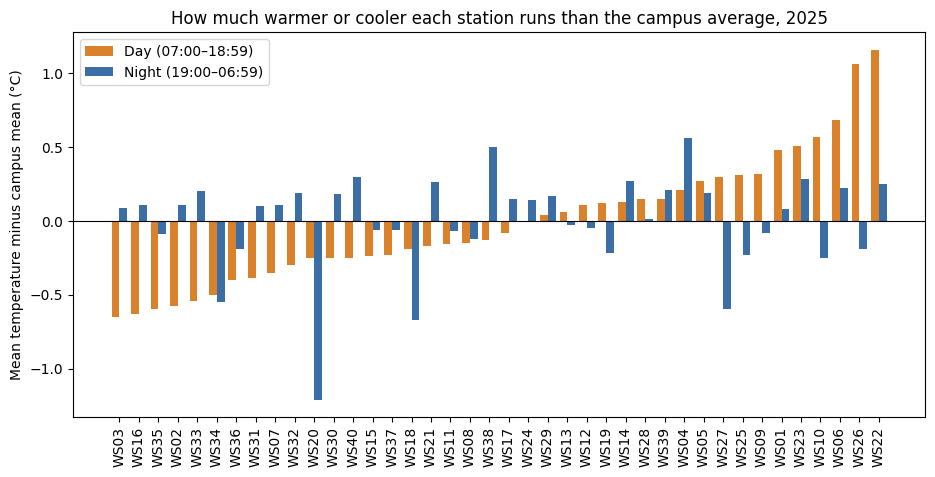

In [142]:
anom = clean.groupby(["Station", "period"])["anomaly"].mean().unstack().round(2)
anom["all_hours"] = clean.groupby("Station")["anomaly"].mean().round(2)
anom["valid_hours"] = clean.groupby("Station")["temp"].count()
anom = anom.sort_values("day", ascending=False)

display(anom.head(8))
display(anom.tail(8))
print("Correlation between day and night anomaly across stations:",
      round(anom["day"].corr(anom["night"]), 2))

plot_df = anom.sort_values("day")
x = np.arange(len(plot_df))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, plot_df["day"],   w, label="Day (07:00–18:59)",   color="#d9822b")
ax.bar(x + w/2, plot_df["night"], w, label="Night (19:00–06:59)", color="#3b6ea5")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylabel("Mean temperature minus campus mean (°C)")
ax.set_title("How much warmer or cooler each station runs than the campus average, 2025")
ax.legend()
fig.savefig("../outputs/figures/station_anomaly.png", dpi=200, bbox_inches="tight")
plt.show()

## 08b. Ground vs rooftop stations

In [143]:
meta = pd.read_csv("../data/processed/station_metadata.csv").set_index("Station")
clean["type"] = clean["Station"].map(meta["type"])

display(meta["type"].value_counts().to_frame("stations"))

by_type = pd.DataFrame({
    "mean wind speed (m/s)": clean.groupby("type")["wind_speed"].mean(),
    "wind flagged by Stage 1 (%)": stat_flag["wind_speed"].groupby(clean["type"]).mean() * 100,
    "day anomaly (°C)": clean[clean["period"] == "day"].groupby("type")["anomaly"].mean(),
    "night anomaly (°C)": clean[clean["period"] == "night"].groupby("type")["anomaly"].mean(),
}).round(2)
display(by_type)

,stations
type,
Ground,32
Roof,5
Roof-3axis,3


,mean wind speed (m/s),wind flagged by Stage 1 (%),day anomaly (°C),night anomaly (°C)
type,,,,
Ground,0.49,1.30,0.03,-0.01
Roof,0.92,8.40,0.14,0.01
Roof-3axis,1.90,56.96,-0.60,0.05


## 09. Preliminary hotspot analysis

Overall share of 'hot' readings (should be about 10%): 10.5


period,day,night,all_hours
Station,,,
WS26,64.6,8.9,36.7
WS22,50.2,21.2,35.7
WS06,29.7,16.6,23.1
WS04,28.9,69.3,49.1
WS23,28.4,33.8,31.1
WS10,23.8,0.0,11.9
WS38,20.8,57.3,39.0
WS27,19.6,0.0,9.8


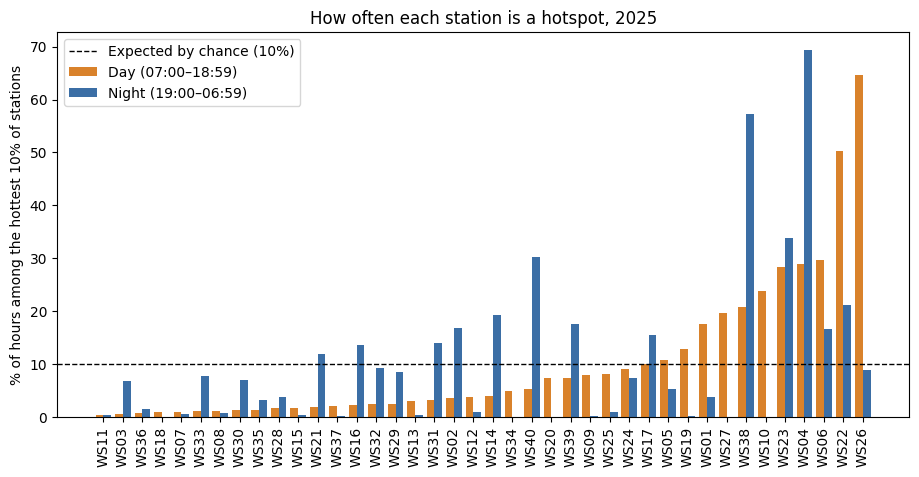

In [144]:
# Only rows with a valid temperature take part in the ranking
valid = clean.dropna(subset=["temp"]).copy()
valid["rank_pct"] = valid.groupby("datetime")["temp"].rank(pct=True)
valid["is_hot"] = valid["rank_pct"] > 0.9      # hottest 10% at that hour

hot_share = (valid.groupby(["Station", "period"])["is_hot"].mean()
                  .unstack() * 100).round(1)
hot_share["all_hours"] = (valid.groupby("Station")["is_hot"].mean() * 100).round(1)
hot_share = hot_share.sort_values("day", ascending=False)

print("Overall share of 'hot' readings (should be about 10%):",
      round(valid["is_hot"].mean() * 100, 1))
display(hot_share.head(8))

plot_df = hot_share.sort_values("day")
x = np.arange(len(plot_df))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, plot_df["day"],   w, label="Day (07:00–18:59)",   color="#d9822b")
ax.bar(x + w/2, plot_df["night"], w, label="Night (19:00–06:59)", color="#3b6ea5")
ax.axhline(10, color="black", linestyle="--", linewidth=1, label="Expected by chance (10%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=90)
ax.set_ylabel("% of hours among the hottest 10% of stations")
ax.set_title("How often each station is a hotspot, 2025")
ax.legend()
fig.savefig("../outputs/figures/hotspot_frequency.png", dpi=200, bbox_inches="tight")
plt.show()

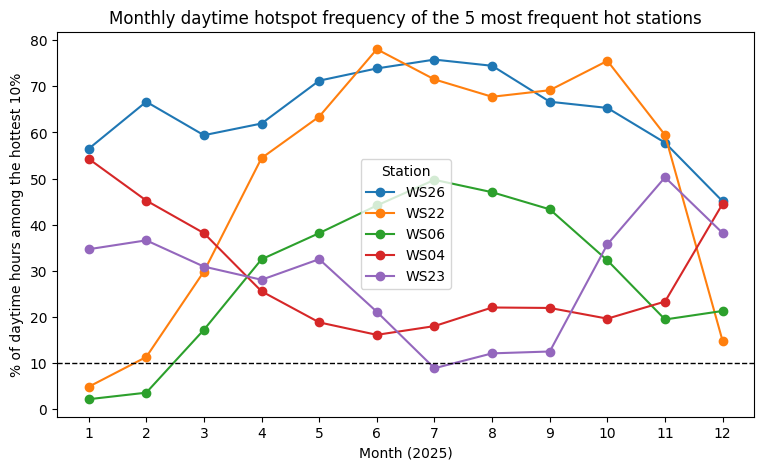

In [145]:
top5 = hot_share.head(5).index
day_valid = valid[valid["period"] == "day"]
monthly = (day_valid.groupby(["month", "Station"])["is_hot"].mean()
                    .unstack()[top5] * 100)

fig, ax = plt.subplots(figsize=(9, 5))
monthly.plot(ax=ax, marker="o")
ax.axhline(10, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Month (2025)")
ax.set_ylabel("% of daytime hours among the hottest 10%")
ax.set_title("Monthly daytime hotspot frequency of the 5 most frequent hot stations")
ax.set_xticks(range(1, 13))
fig.savefig("../outputs/figures/hotspot_monthly.png", dpi=200, bbox_inches="tight")
plt.show()

## 10. Relationships between variables

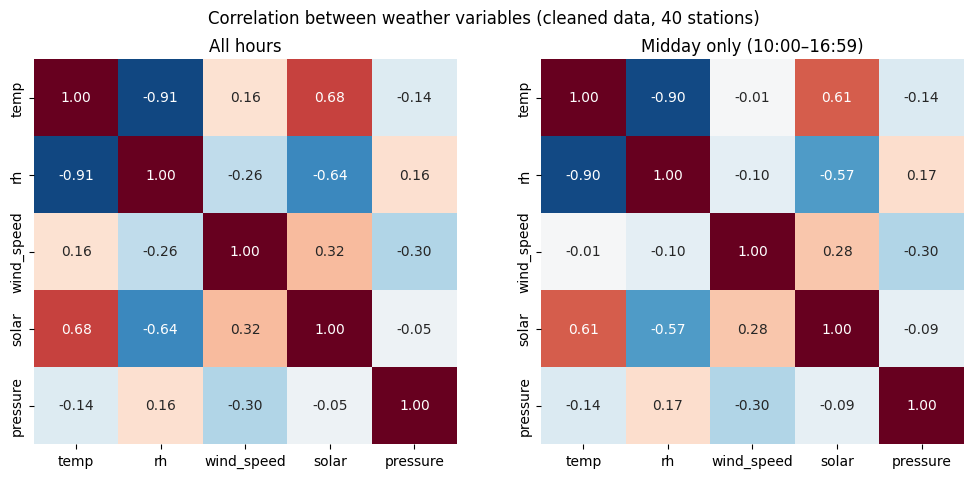

In [146]:
cols = ["temp", "rh", "wind_speed", "solar", "pressure"]
midday = clean[clean["hour"].between(10, 16)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in [(axes[0], clean,  "All hours"),
                        (axes[1], midday, "Midday only (10:00–16:59)")]:
    sns.heatmap(data[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, ax=ax, cbar=False)
    ax.set_title(title)
fig.suptitle("Correlation between weather variables (cleaned data, 40 stations)")
fig.savefig("../outputs/figures/correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Temperature distributions

/var/folders/d1/kqcw_pf56svgnx5skll9nqfw0000gn/T/ipykernel_5126/941690345.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=[s.replace("WS", "") for s in order],


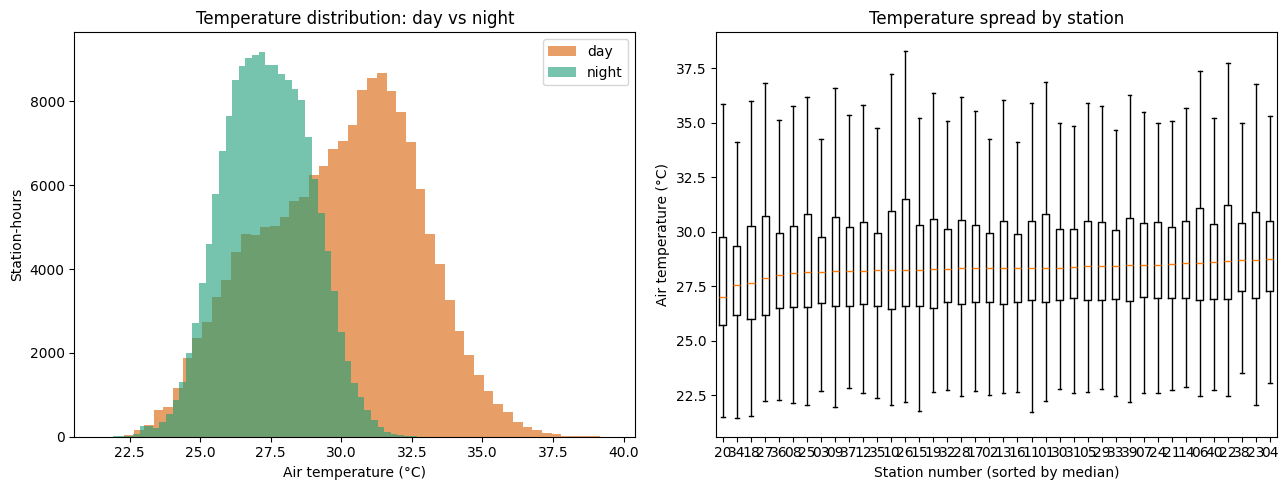

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: how hourly temperature is spread across the whole campus, day vs night
for label, colour in [("day", "#d95f02"), ("night", "#1b9e77")]:
    axes[0].hist(clean.loc[clean["period"] == label, "temp"].dropna(),
                 bins=50, alpha=0.6, label=label, color=colour)
axes[0].set_xlabel("Air temperature (°C)")
axes[0].set_ylabel("Station-hours")
axes[0].set_title("Temperature distribution: day vs night")
axes[0].legend()

# Right: spread per station, ordered by median temperature
order = clean.groupby("Station")["temp"].median().sort_values().index
data = [clean.loc[clean["Station"] == s, "temp"].dropna() for s in order]
axes[1].boxplot(data, labels=[s.replace("WS", "") for s in order],
                showfliers=False)
axes[1].set_xlabel("Station number (sorted by median)")
axes[1].set_ylabel("Air temperature (°C)")
axes[1].set_title("Temperature spread by station")

plt.tight_layout()
plt.savefig("../outputs/figures/temperature_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Where are the stations? (first GIS look)

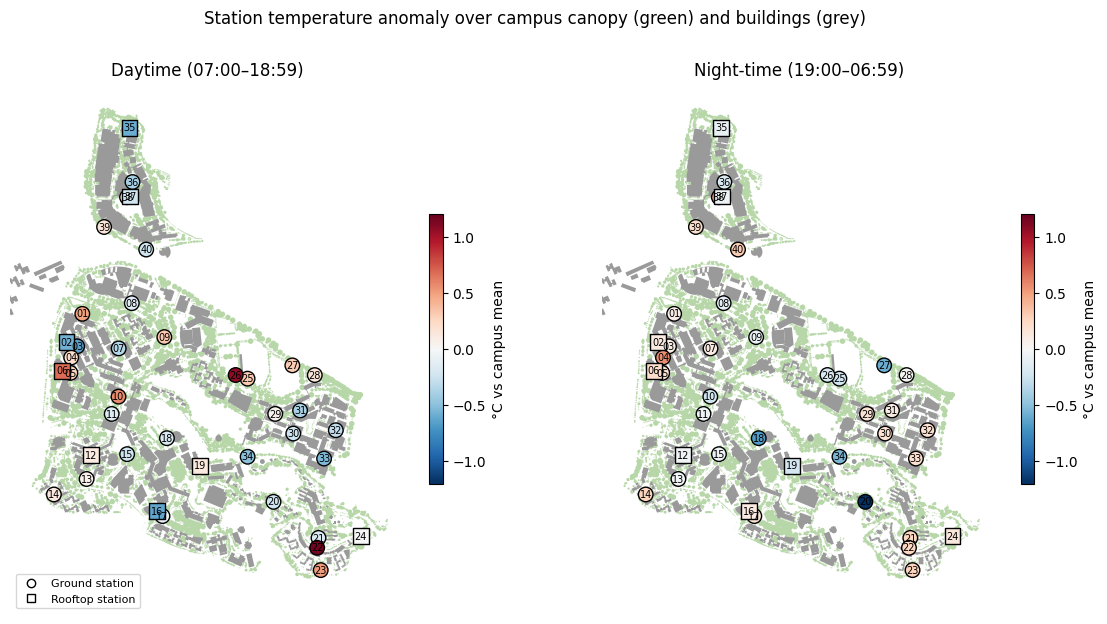

In [148]:
import geopandas as gpd
from matplotlib.lines import Line2D

GIS = Path("../data/raw/gis")
buildings = gpd.read_file(GIS / "nus_campus_map - Buildings.shp").to_crs(3414)
canopy    = gpd.read_file(GIS / "nus_campus_map - TreeCanopy.shp").to_crs(3414)

# One point per station, built from its latitude/longitude
st = clean.groupby("Station")[["lat", "lon"]].first().reset_index()
stations = gpd.GeoDataFrame(
    st, geometry=gpd.points_from_xy(st["lon"], st["lat"]), crs=4326
).to_crs(3414)

# Attach each station's day and night anomaly from the earlier step
stations = stations.merge(anom[["day", "night"]], left_on="Station", right_index=True)
stations["type"] = stations["Station"].map(meta["type"])
stations["rooftop"] = stations["type"] != "Ground"

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
xmin, ymin, xmax, ymax = stations.total_bounds
pad = 200
for ax, col, title in zip(axes, ["day", "night"],
                          ["Daytime (07:00–18:59)", "Night-time (19:00–06:59)"]):
    canopy.plot(ax=ax, color="#b7d7a8", linewidth=0)
    buildings.plot(ax=ax, color="#9a9a9a", linewidth=0)
    stations[~stations["rooftop"]].plot(ax=ax, column=col, cmap="RdBu_r", vmin=-1.2, vmax=1.2,
                  markersize=110, marker="o", edgecolor="black", legend=True,
                  legend_kwds={"label": "°C vs campus mean", "shrink": 0.5})
    stations[stations["rooftop"]].plot(ax=ax, column=col, cmap="RdBu_r", vmin=-1.2, vmax=1.2,
                  markersize=130, marker="s", edgecolor="black")
    for _, r in stations.iterrows():
        ax.annotate(r["Station"][2:], (r.geometry.x, r.geometry.y),
                    fontsize=7, ha="center", va="center")
    ax.set_xlim(xmin - pad, xmax + pad)
    ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)
axes[0].legend(handles=[Line2D([], [], marker="o", ls="", mfc="white", mec="black", label="Ground station"),
                        Line2D([], [], marker="s", ls="", mfc="white", mec="black", label="Rooftop station")],
               loc="lower left", fontsize=8)
fig.suptitle("Station temperature anomaly over campus canopy (green) and buildings (grey)")
fig.savefig("../outputs/figures/station_map_anomaly.png", dpi=200, bbox_inches="tight")
plt.show()